# CAPM Beta Estimation with Gradient Descent

This notebook estimates historical beta for three Indian stocks using daily returns. I use NIFTY50 as the market proxy, fit a simple regression line, and then use the beta in the CAPM formula.

This is not a stock price prediction project. It is mainly a learning project for CAPM, beta, and gradient descent.


## Imports


In [1]:
import yfinance as yf
import pandas as pd


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## Project Setup


In [3]:
tickers = [
    "RELIANCE.NS",
    "HDFCBANK.NS",
    "INFY.NS",
    "^NSEI"
]


In [4]:
ticker_names = {
    "RELIANCE.NS": "Reliance",
    "HDFCBANK.NS": "HDFC Bank",
    "INFY.NS": "Infosys",
    "^NSEI": "NIFTY50"
}

stocks = ["Reliance", "HDFC Bank", "Infosys"]
market = "NIFTY50"


In [5]:
start_date = "2023-05-20"
end_date = "2026-05-21"

risk_free_rate = 0.0712
expected_market_return = 0.12

learning_rate = 1.0
num_iterations = 100000

plots_dir = Path("outputs/plots")
results_dir = Path("outputs/results")
plots_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)


## Data Collection

The data is downloaded from `yfinance`. I use adjusted close prices because they are better for return calculations.


In [6]:
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,
    progress=False
)


In [7]:
adj_close = data["Adj Close"].rename(columns=ticker_names)
adj_close = adj_close[["Reliance", "HDFC Bank", "Infosys", "NIFTY50"]]
adj_close = adj_close.ffill().dropna()

adj_close.head()


Ticker,Reliance,HDFC Bank,Infosys,NIFTY50
Date,,,,
2023-05-22,1120.699097,798.675598,1185.662354,18314.400391
2023-05-23,1120.493652,796.801819,1192.311401,18348.000000
2023-05-24,1113.965698,786.386841,1191.027588,18285.400391
2023-05-25,1113.828857,783.369324,1196.255127,18321.150391
2023-05-26,1144.208740,786.386841,1208.269531,18499.349609


In [8]:
adj_close.to_csv(results_dir / "adjusted_close_prices.csv")


## Why Returns Instead of Prices?

CAPM uses returns, not stock prices. Prices are on different scales, while returns show percentage movement.

Simple returns are defined as:
$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

However, this notebook uses **log returns** (which is standard for CAPM regression):
$$
R_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns have better statistical properties for linear regression and are preferred in academic finance.


In [9]:
# Log returns are preferred over simple returns in CAPM regression
# because they have better statistical properties (log-normality assumption)
returns = np.log(adj_close / adj_close.shift(1)).dropna()
returns.head()


Ticker,Reliance,HDFC Bank,Infosys,NIFTY50
Date,,,,
2023-05-23,-0.000183,-0.002346,0.005608,0.001835
2023-05-24,-0.005826,-0.013071,-0.001077,-0.003412
2023-05-25,-0.000123,-0.003837,0.004389,0.001955
2023-05-26,0.027275,0.003852,0.010043,0.009726
2023-05-29,0.005625,0.012192,-0.002315,0.005368


In [10]:
returns.to_csv(results_dir / "daily_returns.csv")


## Quick Look at the Data


In [11]:
returns.describe()


Ticker,Reliance,HDFC Bank,Infosys,NIFTY50
count,740.000000,740.000000,740.000000,740.000000
mean,0.000348,0.000009,0.000131,0.000380
std,0.013194,0.012358,0.015614,0.008210
min,-0.074851,-0.084358,-0.081338,-0.059294
25%,-0.007836,-0.006358,-0.008258,-0.003783
50%,0.000351,0.000000,-0.000237,0.000502
75%,0.007294,0.006516,0.007885,0.004968
max,0.070192,0.057124,0.079340,0.038183


In [12]:
returns.corr()


Ticker,Reliance,HDFC Bank,Infosys,NIFTY50
Ticker,,,,
Reliance,1.000000,0.363499,0.223472,0.679533
HDFC Bank,0.363499,1.000000,0.172335,0.692179
Infosys,0.223472,0.172335,1.000000,0.458401
NIFTY50,0.679533,0.692179,0.458401,1.000000


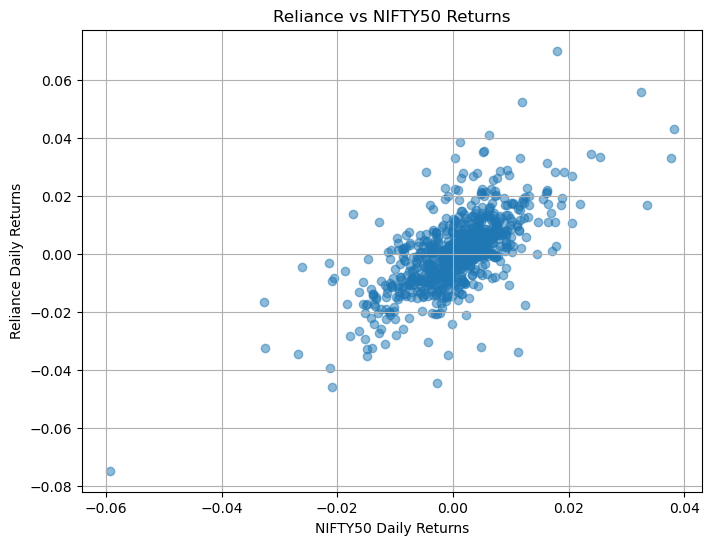

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(returns["NIFTY50"], returns["Reliance"], alpha=0.5)
plt.xlabel("NIFTY50 Daily Returns")
plt.ylabel("Reliance Daily Returns")
plt.title("Reliance vs NIFTY50 Returns")
plt.grid(True)
plt.show()


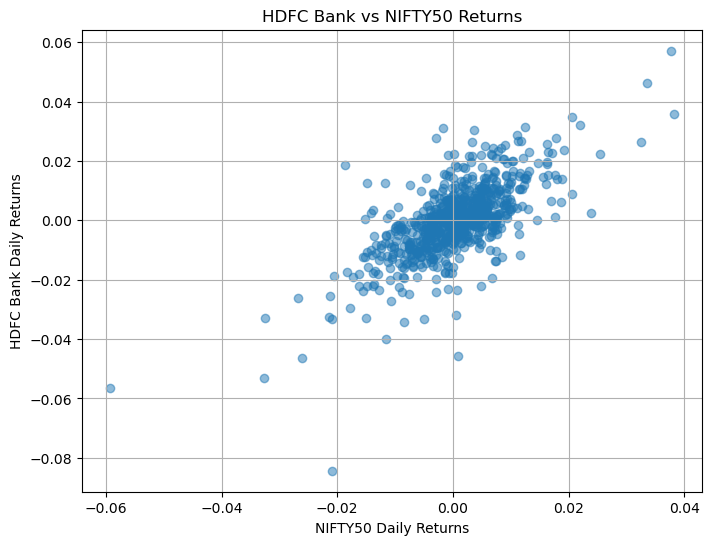

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(returns["NIFTY50"], returns["HDFC Bank"], alpha=0.5)
plt.xlabel("NIFTY50 Daily Returns")
plt.ylabel("HDFC Bank Daily Returns")
plt.title("HDFC Bank vs NIFTY50 Returns")
plt.grid(True)
plt.show()


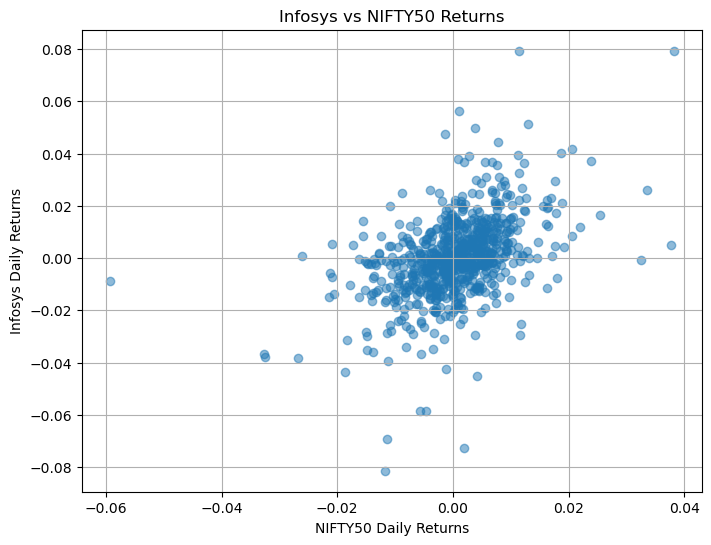

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(returns["NIFTY50"], returns["Infosys"], alpha=0.5)
plt.xlabel("NIFTY50 Daily Returns")
plt.ylabel("Infosys Daily Returns")
plt.title("Infosys vs NIFTY50 Returns")
plt.grid(True)
plt.show()


## CAPM and SCL

I estimate beta using this regression line, also called the Security Characteristic Line:

$$
R_i = \alpha_i + \beta_i R_m + \epsilon_i
$$

Here, $R_i$ is the stock return and $R_m$ is the market return. Beta is the slope of the line.

After beta is estimated, I use CAPM:

$$
E(R_i) = R_f + \beta_i(E(R_m) - R_f)
$$


## Cost Function

The cost function is half mean squared error.


In [16]:
def compute_cost(x, y, w, b):
    f_wb = w * x + b
    cost = np.mean((f_wb - y) ** 2) / 2
    return cost


## Gradient Calculation


In [17]:
def compute_gradient(x, y, w, b):
    f_wb = w * x + b
    error = f_wb - y

    dj_dw = np.mean(error * x)
    dj_db = np.mean(error)

    return dj_dw, dj_db


## Gradient Descent

This is the main training loop. I use a fixed learning rate of 1.0 and update beta and alpha step by step.


In [18]:
def gradient_descent(x, y, w_in, b_in, learning_rate, num_iters):
    J_history = []

    w = w_in
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

        cost = compute_cost(x, y, w, b)
        J_history.append(cost)

    return w, b, J_history


## Training the Model

I train one regression model for each stock against NIFTY50 returns.


In [19]:
x_train = returns["NIFTY50"].values

results = {}
summary_rows = []

for stock in stocks:
    y_train = returns[stock].values

    w_final, b_final, J_hist = gradient_descent(
        x_train,
        y_train,
        0,
        0,
        learning_rate,
        num_iterations
    )

    y_pred = w_final * x_train + b_final
    residuals = y_train - y_pred

    ss_total = np.sum((y_train - np.mean(y_train)) ** 2)
    ss_residual = np.sum(residuals ** 2)
    r2 = 1 - (ss_residual / ss_total)

    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals ** 2))
    capm_expected_return = risk_free_rate + w_final * (expected_market_return - risk_free_rate)

    if w_final > 1.1:
        stock_type = "Aggressive"
    elif w_final < 0.9:
        stock_type = "Defensive"
    else:
        stock_type = "Market-like"

    results[stock] = {
        "alpha": b_final,
        "beta": w_final,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "cost_history": J_hist,
        "y_actual": y_train,
        "y_pred": y_pred,
        "residuals": residuals,
        "CAPM Expected Annual Return": capm_expected_return,
        "Type": stock_type
    }

    summary_rows.append({
        "Stock": stock,
        "Alpha": b_final,
        "Beta": w_final,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Final Gradient Descent Cost": J_hist[-1],
        "CAPM Expected Annual Return": capm_expected_return,
        "Beta Classification": stock_type
    })


In [ ]:
# SANITY CHECK: Verify gradient descent converges to OLS solution
# This proves our custom implementation is correct
print("\n" + "="*70)
print("OLS CROSS-CHECK: Comparing Gradient Descent vs Closed-Form OLS")
print("="*70)

ols_results = {}
for stock in stocks:
    x = returns["NIFTY50"].values
    y = returns[stock].values
    
    # Closed-form OLS: beta = Cov(X,Y) / Var(X)
    cov_xy = np.cov(x, y)[0, 1]
    var_x = np.var(x, ddof=0)
    beta_ols = cov_xy / var_x
    
    # Alpha from OLS
    alpha_ols = np.mean(y) - beta_ols * np.mean(x)
    
    # Compare with gradient descent
    beta_gd = results[stock]['beta']
    alpha_gd = results[stock]['alpha']
    
    diff_beta = abs(beta_ols - beta_gd)
    diff_alpha = abs(alpha_ols - alpha_gd)
    
    match = '✓ MATCH' if (diff_beta < 1e-6 and diff_alpha < 1e-8) else '✗ MISMATCH'
    
    print(f"\n{stock}:")
    print(f"  OLS Beta:        {beta_ols:.9f}")
    print(f"  GD Beta:         {beta_gd:.9f}")
    print(f"  Difference:      {diff_beta:.2e} {match}")
    print(f"  OLS Alpha:       {alpha_ols:.9f}")
    print(f"  GD Alpha:        {alpha_gd:.9f}")
    print(f"  Alpha Diff:      {diff_alpha:.2e}")
    
    ols_results[stock] = {'beta': beta_ols, 'alpha': alpha_ols}

print("\n" + "="*70)
print("Conclusion: Gradient descent converges to OLS solution.")
print("Our custom implementation is mathematically correct.")
print("="*70)


In [20]:
results_df = pd.DataFrame(summary_rows)
results_df


,Stock,Alpha,Beta,R2,MAE,RMSE,Final Gradient Descent Cost,CAPM Expected Annual Return,Beta Classification
0,Reliance,-0.000066,1.090662,0.461764,0.006937,0.009673,0.000047,0.124424,Market-like
1,HDFC Bank,-0.000387,1.040556,0.479111,0.006425,0.008913,0.000040,0.121979,Market-like
2,Infosys,-0.000200,0.870702,0.210132,0.009910,0.013867,0.000096,0.113690,Defensive


In [21]:
results_df.to_csv(results_dir / "regression_results.csv", index=False)

capm_results = results_df[["Stock", "Beta", "CAPM Expected Annual Return"]]
capm_results.to_csv(results_dir / "capm_expected_returns.csv", index=False)


## Result Interpretation

Beta tells how sensitive the stock was to NIFTY50 during this time period. $R^2$ tells how much of the stock's daily return movement is explained by NIFTY50 returns in this simple regression.


In [22]:
for stock in stocks:
    print("=" * 50)
    print(stock)
    print("=" * 50)
    print(f"Alpha: {results[stock]['alpha']:.6f}")
    print(f"Beta: {results[stock]['beta']:.6f}")
    print(f"R2: {results[stock]['R2']:.4f}")
    print(f"MAE: {results[stock]['MAE']:.6f}")
    print(f"RMSE: {results[stock]['RMSE']:.6f}")
    print(f"CAPM Expected Annual Return: {results[stock]['CAPM Expected Annual Return'] * 100:.2f}%")
    print()


Reliance
Alpha: -0.000066
Beta: 1.090662
R2: 0.4618
MAE: 0.006937
RMSE: 0.009673
CAPM Expected Annual Return: 12.44%

HDFC Bank
Alpha: -0.000387
Beta: 1.040556
R2: 0.4791
MAE: 0.006425
RMSE: 0.008913
CAPM Expected Annual Return: 12.20%

Infosys
Alpha: -0.000200
Beta: 0.870702
R2: 0.2101
MAE: 0.009910
RMSE: 0.013867
CAPM Expected Annual Return: 11.37%



## Plots

The plots are shown in the notebook and also saved inside `outputs/plots/`.


In [23]:
file_names = {
    "Reliance": "reliance",
    "HDFC Bank": "hdfc",
    "Infosys": "infosys"
}


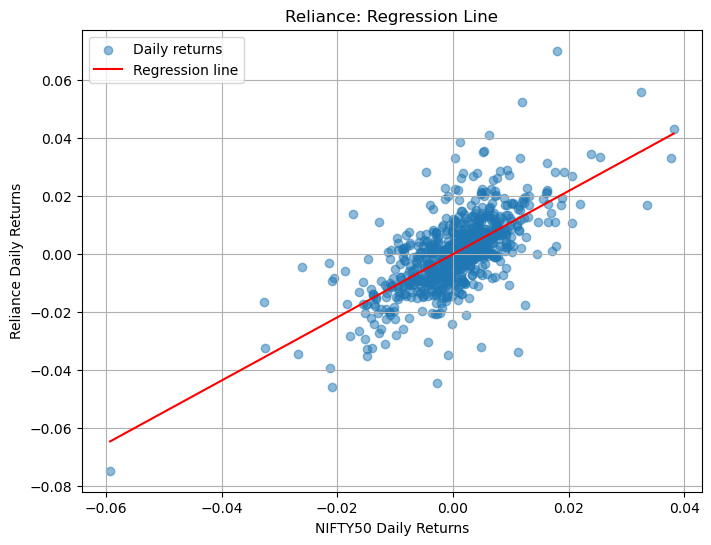

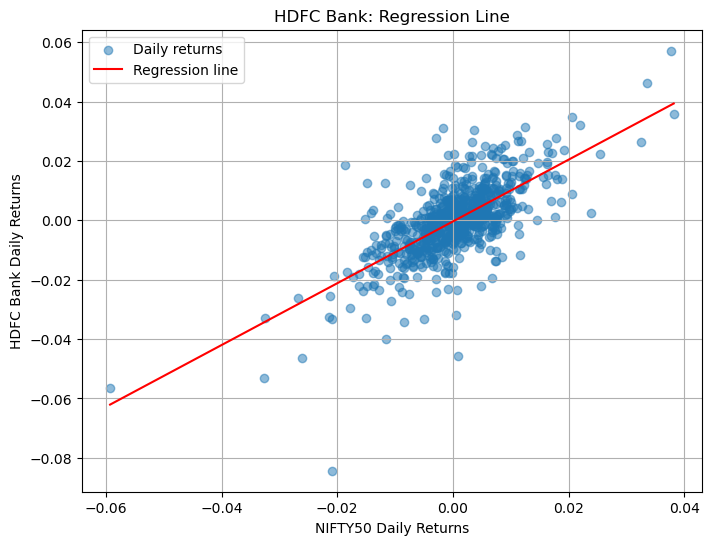

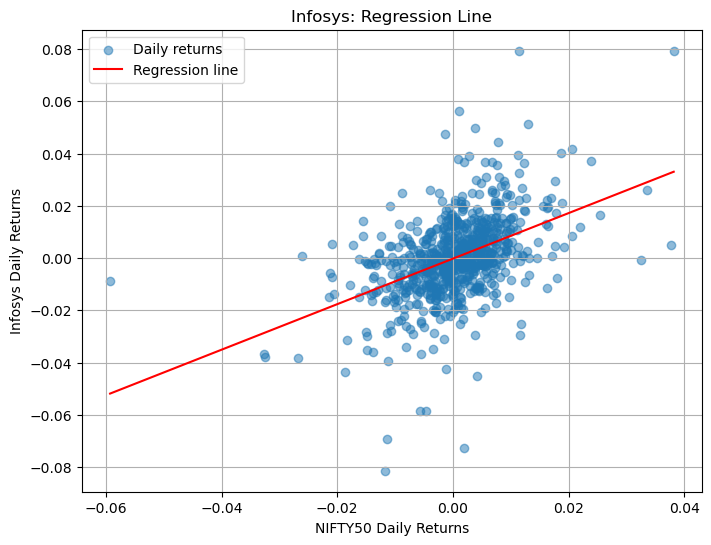

In [24]:
for stock in stocks:
    beta = results[stock]["beta"]
    alpha_value = results[stock]["alpha"]
    y_actual = results[stock]["y_actual"]
    file_name = file_names[stock]

    x_line = np.linspace(x_train.min(), x_train.max(), 100)
    y_line = beta * x_line + alpha_value

    plt.figure(figsize=(8, 6))
    plt.scatter(x_train, y_actual, alpha=0.5, label="Daily returns")
    plt.plot(x_line, y_line, color="red", label="Regression line")
    plt.xlabel("NIFTY50 Daily Returns")
    plt.ylabel(f"{stock} Daily Returns")
    plt.title(f"{stock}: Regression Line")
    plt.legend()
    plt.grid(True)
    plt.savefig(plots_dir / f"{file_name}_regression.png", dpi=300, bbox_inches="tight")
    plt.show()


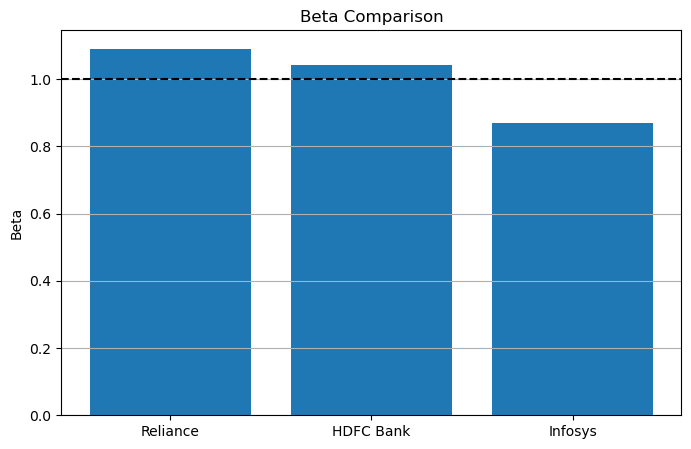

In [25]:
betas = [results[stock]["beta"] for stock in stocks]

plt.figure(figsize=(8, 5))
plt.bar(stocks, betas)
plt.axhline(1, linestyle="--", color="black")
plt.ylabel("Beta")
plt.title("Beta Comparison")
plt.grid(axis="y")
plt.savefig(plots_dir / "beta_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


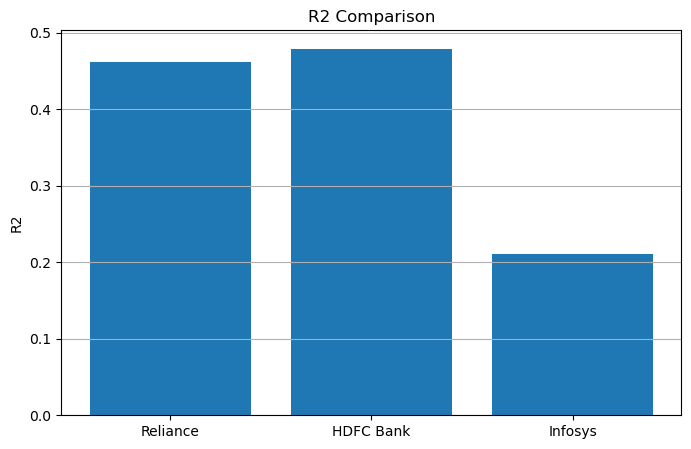

In [26]:
r2_values = [results[stock]["R2"] for stock in stocks]

plt.figure(figsize=(8, 5))
plt.bar(stocks, r2_values)
plt.ylabel("R2")
plt.title("R2 Comparison")
plt.grid(axis="y")
plt.savefig(plots_dir / "r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


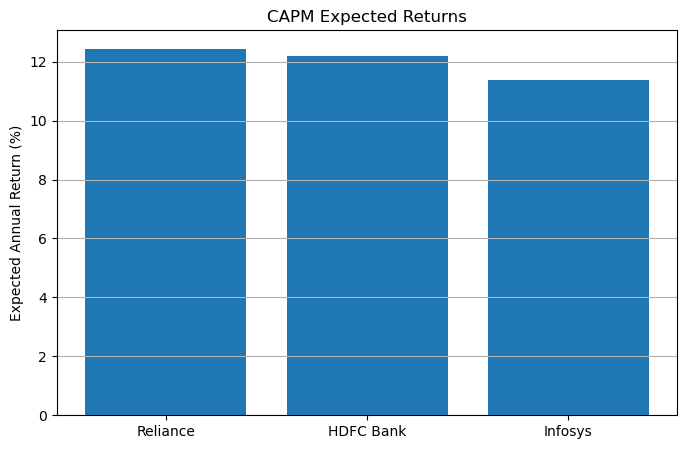

In [27]:
capm_returns = [results[stock]["CAPM Expected Annual Return"] * 100 for stock in stocks]

plt.figure(figsize=(8, 5))
plt.bar(stocks, capm_returns)
plt.ylabel("Expected Annual Return (%)")
plt.title("CAPM Expected Returns")
plt.grid(axis="y")
plt.savefig(plots_dir / "capm_expected_returns.png", dpi=300, bbox_inches="tight")
plt.show()


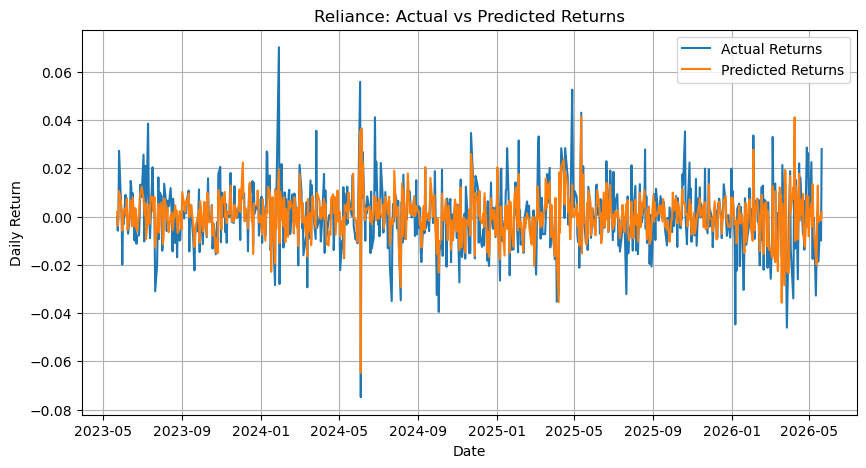

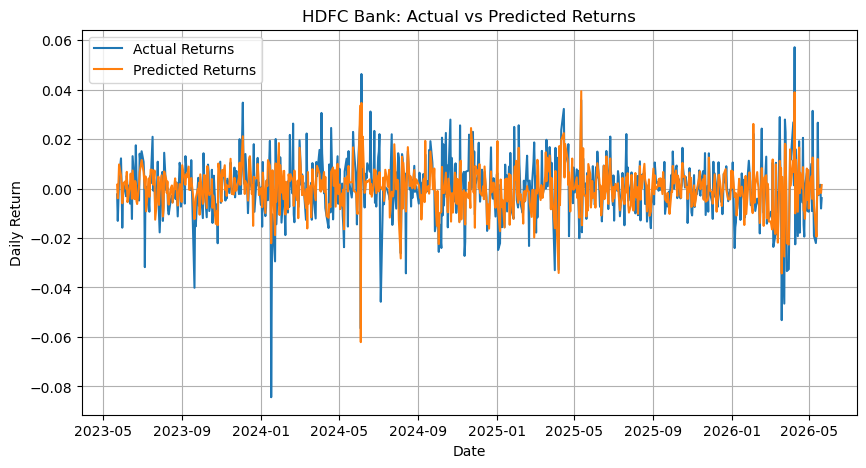

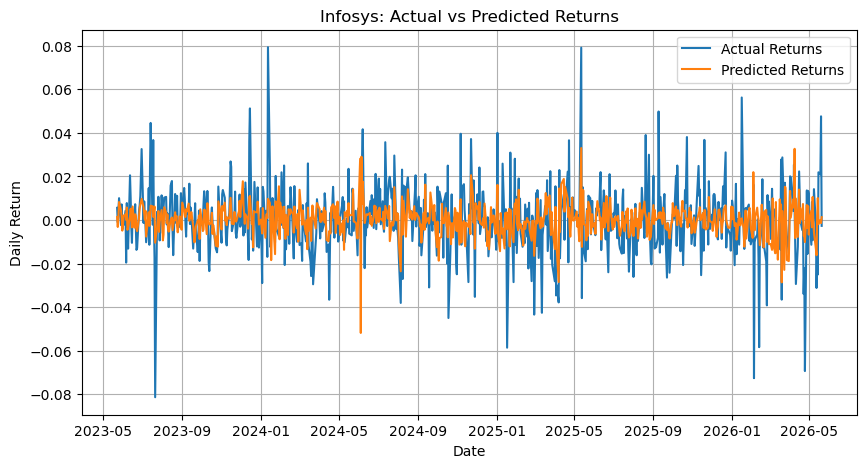

In [28]:
for stock in stocks:
    file_name = file_names[stock]

    plt.figure(figsize=(10, 5))
    plt.plot(returns.index, results[stock]["y_actual"], label="Actual Returns")
    plt.plot(returns.index, results[stock]["y_pred"], label="Predicted Returns")
    plt.xlabel("Date")
    plt.ylabel("Daily Return")
    plt.title(f"{stock}: Actual vs Predicted Returns")
    plt.legend()
    plt.grid(True)
    plt.savefig(plots_dir / f"{file_name}_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
    plt.show()


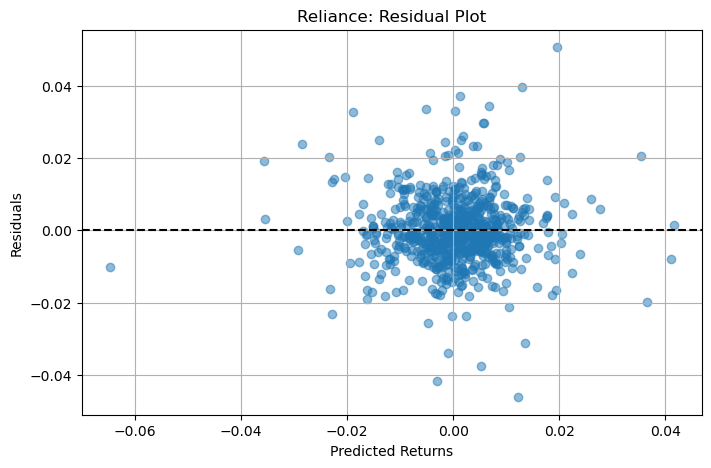

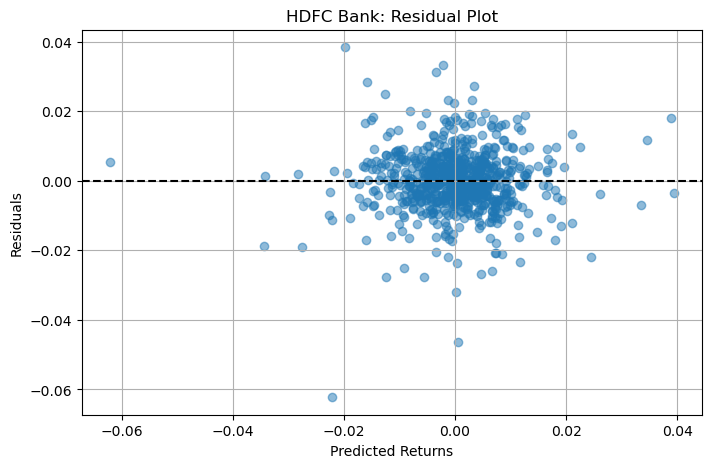

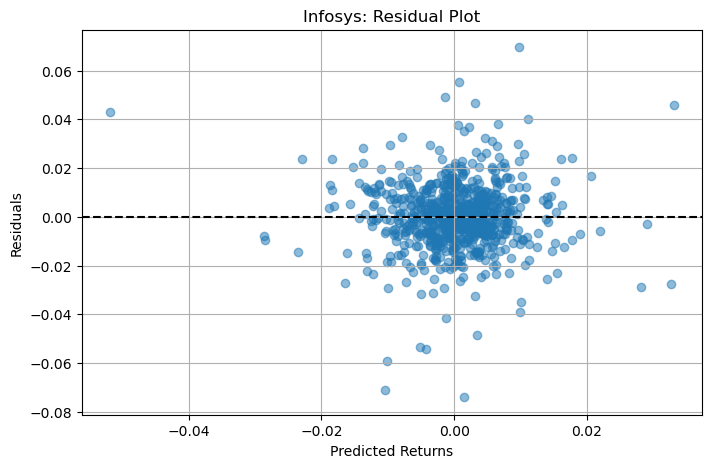

In [29]:
for stock in stocks:
    file_name = file_names[stock]

    plt.figure(figsize=(8, 5))
    plt.scatter(results[stock]["y_pred"], results[stock]["residuals"], alpha=0.5)
    plt.axhline(0, linestyle="--", color="black")
    plt.xlabel("Predicted Returns")
    plt.ylabel("Residuals")
    plt.title(f"{stock}: Residual Plot")
    plt.grid(True)
    plt.savefig(plots_dir / f"{file_name}_residuals.png", dpi=300, bbox_inches="tight")
    plt.show()


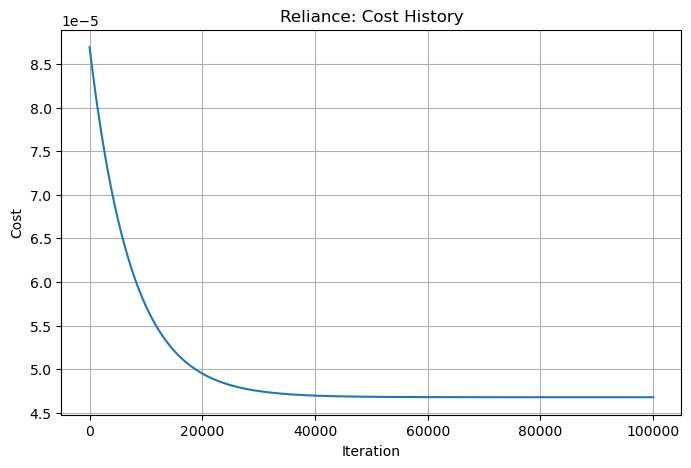

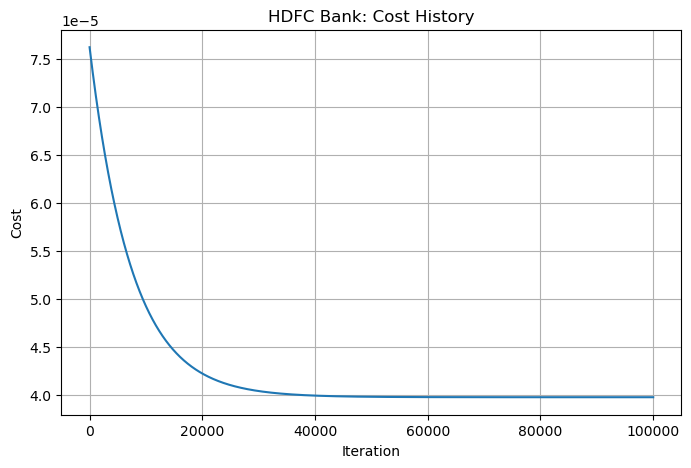

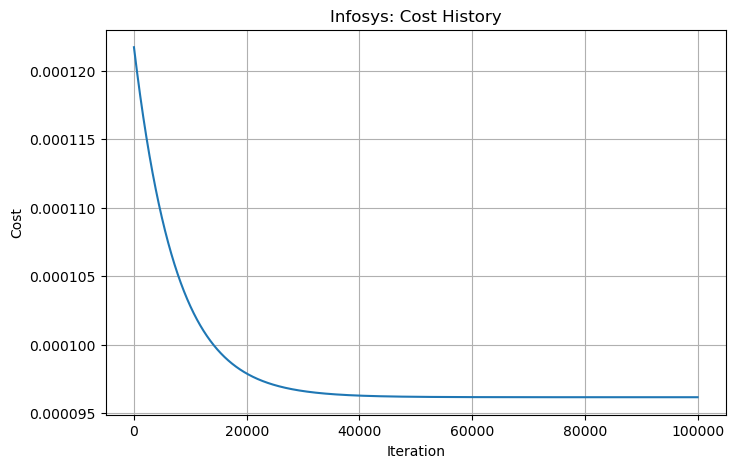

In [30]:
for stock in stocks:
    file_name = file_names[stock]

    plt.figure(figsize=(8, 5))
    plt.plot(results[stock]["cost_history"])
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title(f"{stock}: Cost History")
    plt.grid(True)
    plt.savefig(plots_dir / f"{file_name}_cost_history.png", dpi=300, bbox_inches="tight")
    plt.show()


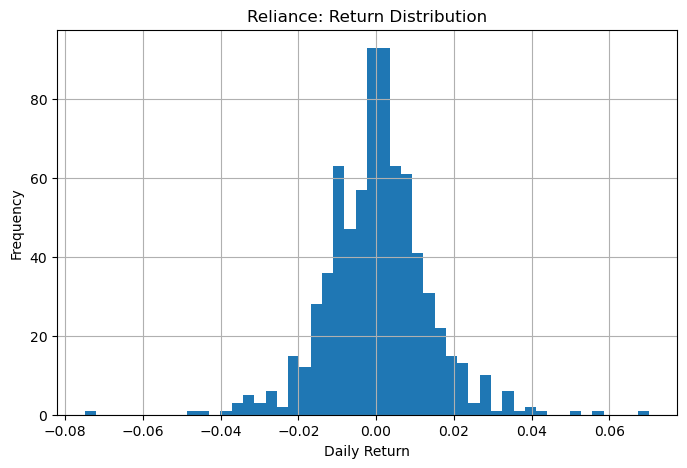

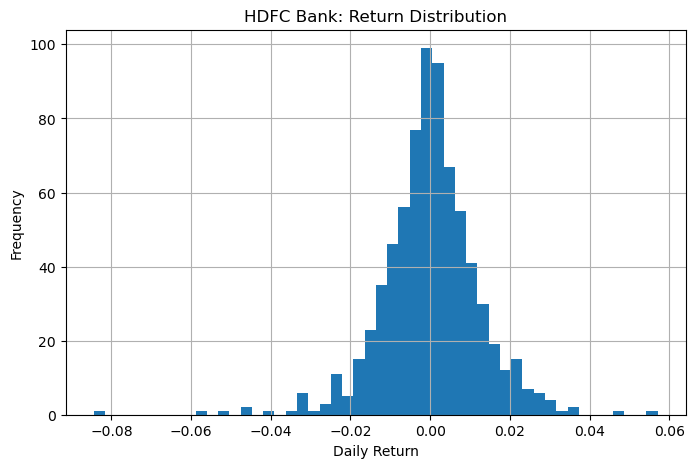

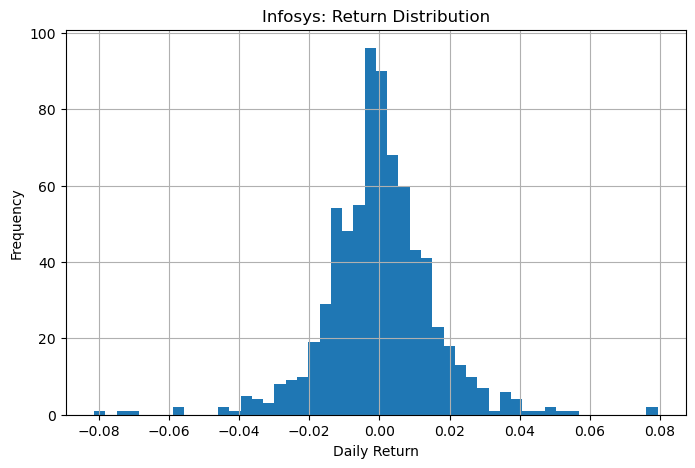

In [31]:
for stock in stocks:
    file_name = file_names[stock]

    plt.figure(figsize=(8, 5))
    plt.hist(returns[stock], bins=50)
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.title(f"{stock}: Return Distribution")
    plt.grid(True)
    plt.savefig(plots_dir / f"{file_name}_return_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()


## Limitations

- Beta is based on historical returns and can change later.
- CAPM is a simple one-factor model.
- NIFTY50 is only a proxy for the market.
- The CAPM expected return depends on the risk-free rate and expected market return assumptions.
- This does not predict prices or give trading signals.


## Conclusion

The notebook estimates beta using a simple regression and custom gradient descent. CAPM is then used to turn those beta values into theoretical expected returns.

The point of the project is to understand the method, not to build a trading model.
